<h1>Problem</h1>
<h4>Handwritten English Character Recognition Using Classical Vision & Machine Learning</h4>

<h2>Goal</h2>
<p>Develop a classical computer-vision-based recognition system for handwritten English
letters (A–Z). The system must use low-level and mid-level feature extraction and train
classical ML models on the EMNIST Letters dataset. The trained system will then evaluate
a real handwritten sample provided by the student.</p>

<h3>Part 1 – Dataset Selection & Preparation</h3>
<p>1. Load the EMNIST Letters dataset.
2. Optionally sample 10k–20k images.
3. Normalize images to 28×28 grayscale.
4. Ensure labels correspond to characters A–Z.
5. Collect one real handwritten test image (scanned or photographed).</p>

In [4]:
import torch
from torchvision import datasets, transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import pandas as pd

from skimage.feature import local_binary_pattern
from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import seaborn as sns
#from scipy.stats import itemfreq # Used for LBP Histogram

In [5]:
def print_header(msg):
    print("========================================")
    print(msg)
    print("========================================")

<h4>Part 1.1: Load the EMNIST Letters dataset.</h4>

<p>
Both full PCA and randomized PCA achieve similar classification accuracy (≈30%) when their top-K eigenvectors (95% variance) are used as features for logistic regression.

This similarity is expected because randomized PCA is designed to approximate the same principal subspace as full PCA.
</p>

In [8]:
# --- Configuration ---
SAMPLES_TO_USE = 20000 # Max total samples is 145,600 (Train + Test)
RANDOM_STATE = 42
IMG_SIZE = 28
# EMNIST Letters: Labels 1-26 correspond to A-Z. We map to 0-25.
NUM_CLASSES = 26

In [9]:
##Define the transformer to convert the loaded data set to tensor and normalize
transform = transforms.Compose(
    transforms.ToTensor()
)

#Loading the training dataset
train_dataset = datasets.EMNIST(
    root = './data',
    split='letters',
    train=True,
    download=True,
    transform=transform
)

#Loading the training dataset
test_dataset = datasets.EMNIST(
    root = './data',
    split='letters',
    train=False,
    download=True,
    transform=transform
)

#Combining the training and test data set
full_data_tensor = torch.cat([train_dataset.data, test_dataset.data], dim=0)
full_labels_tensor = torch.cat([train_dataset.targets, test_dataset.targets], dim=0)


<h4>Part 1.2: Sample 10k–20k images..</h4>

In [11]:
if SAMPLES_TO_USE > len(full_data_tensor):
    SAMPLES_TO_USE = len(full_data_tensor)
    print("Warning: Sample size requested is larger than total data.")

np.random.seed(RANDOM_STATE)

sample_indices = np.random.choice(len(full_data_tensor), SAMPLES_TO_USE, replace=False)

#Apply selection to the tensors
X_sample_tensor = full_data_tensor[sample_indices]
y_sample_tensor = full_labels_tensor[sample_indices]


<h4>Part 1.3: Normalize images</h4>

In [13]:
# PyTorch EMNIST stores data as (N, 28, 28) with values 0-255.
# We convert to float and normalize to 0-1, and ensure the shape is (N, 28, 28)
X_normalized_numpy = X_sample_tensor.float().numpy() / 255.0

# 4. Ensure labels correspond to characters A–Z.
# EMNIST letters targets are 1-26. Convert to 0-25 for ML models.
y_labels_int = y_sample_tensor.numpy().astype(int) - 1

<h4>Part 1.4: Ensure labels correspond to characters A–Z.</h4>

In [15]:
# Map integer labels (0-25) to actual letters (A-Z) for display/reporting
y_labels_mapped = np.vectorize(lambda x: chr(ord('A') + x))(y_labels_int)

In [16]:
# --- Final Data Split ---
# Split the sampled data into training and test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_normalized_numpy, y_labels_int, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels_int
)
# Keep mapped labels for reporting
_, _, y_train_mapped, y_test_mapped = train_test_split(
    X_normalized_numpy, y_labels_mapped, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels_mapped
)


--- Data Verification ---
Total Samples Used: 20000
Image Shape: 28x28 (normalized to 0-1)
Training Set Size: 16000
Test Set Size: 4000
Example Label: A (Internal Code: 0)


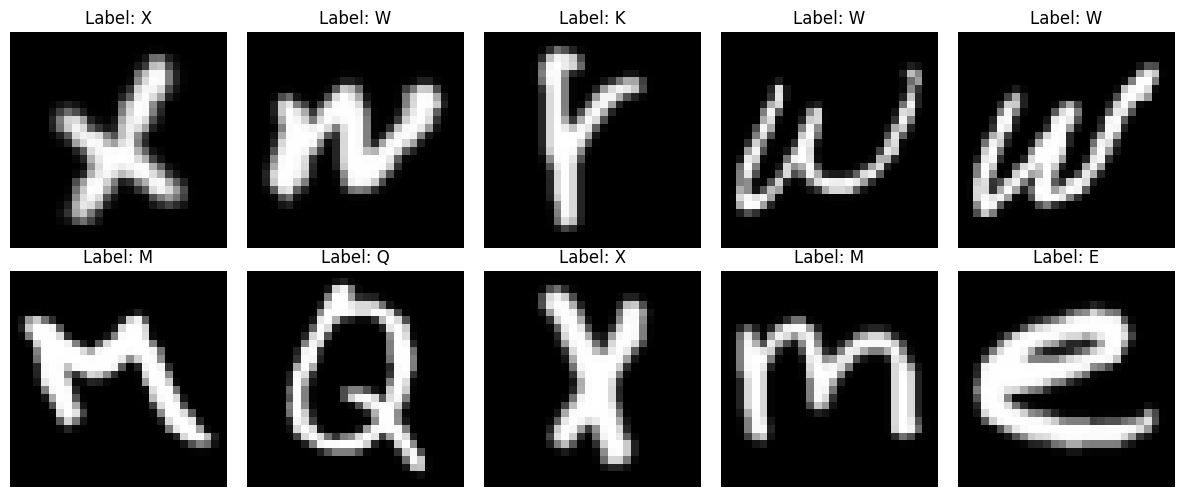

In [17]:
########
#SHOWING input data
########

print("\n--- Data Verification ---")
print(f"Total Samples Used: {X_normalized_numpy.shape[0]}")
print(f"Image Shape: {X_train_raw.shape[1]}x{X_train_raw.shape[2]} (normalized to 0-1)")
print(f"Training Set Size: {X_train_raw.shape[0]}")
print(f"Test Set Size: {X_test_raw.shape[0]}")
print(f"Example Label: {y_labels_mapped[0]} (Internal Code: {y_labels_int[0]})")

# Display a sample image
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten() # Flatten the 2x5 array of axes for easy indexing

for idx in range (0, 10):
    img = X_train_raw[idx]
    label = y_train_mapped[idx]
    
    # EMNIST images often require a transpose/rotation correction 
    # to display and process correctly (white writing on black background).
    img_corrected = np.transpose(img, (1, 0))
    
    axes[idx].imshow(img_corrected, cmap='gray', interpolation='nearest')
    axes[idx].set_title(f"Label: {label}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

<h3>Part 2 – Preprocessing and Feature Extraction</h3>
<p>Apply classical image processing operations:
Low-Level Features:
<br>
Convert to grayscale
Apply histogram normalization/equalization
Apply Gaussian or median blur
Mid-Level Features:
<br>
Sobel/Canny edge detection
Extract contours or connected components
Compute texture descriptors like LBP
Compute ORB keypoints if applicable
Goal: Create a feature vector of 3–5 features per image and store all features in a matrix.</p>

In [19]:
import numpy as np
import cv2
from skimage.feature import local_binary_pattern

def extract_limited_features(img_normalized):
    """
    Extracting feature vector of exactly 5 aggregated features 
    (LBP, Canny, Contour) to meet the assignment constraint.
    """
    # Convert to 0-255 uint8 for OpenCV operations
    img_cv = (img_normalized * 255).astype(np.uint8)
    
    # Simple Thresholding (assuming clean input after preprocessing steps)
    _, img_binarized = cv2.threshold(img_cv, 100, 255, cv2.THRESH_BINARY)
    
    # ------------------ MID-LEVEL FEATURE CALCULATION ------------------

    # A. Texture Descriptor (LBP)
    # LBP is used, but its output is immediately averaged to meet the 5-feature limit.
    n_points = 8
    radius = 1
    # local_binary_pattern returns an array of LBP codes for each pixel
    lbp_map = local_binary_pattern(img_cv, n_points, radius, method='uniform')
    
    # B. Structural Descriptor (Canny)
    edges = cv2.Canny(img_cv, 50, 150)
    
    # C. Geometric/Topological Descriptors (Contours)
    # Use RETR_TREE to find both outer and inner contours (holes)
    contours, hierarchy = cv2.findContours(img_binarized, 
                                           cv2.RETR_TREE, 
                                           cv2.CHAIN_APPROX_SIMPLE)
    
    # ------------------ AGGREGATION AND FEATURE VECTOR CONSTRUCTION ------------------
    
    features = []

    # 1. Feature: Average LBP Value (Aggregation of Texture)
    # Average LBP value across the entire image
    avg_lbp_value = np.mean(lbp_map) 
    features.append(avg_lbp_value)

    # 2. Feature: Canny Edge Density (Aggregation of Structure)
    # Ratio of edge pixels to total pixels
    canny_edge_density = np.sum(edges > 0) / edges.size
    features.append(canny_edge_density)

    # Initialize geometric/topological features
    max_aspect_ratio = 0.0
    max_area = 0.0
    num_holes = 0

    if contours:
        # Get the largest contour for geometric features
        c = max(contours, key=cv2.contourArea)
        
        # 3. Feature: Max Contour Area (Geometric)
        max_area = cv2.contourArea(c)
        
        # 4. Feature: Aspect Ratio (Geometric)
        x, y, w, h = cv2.boundingRect(c)
        max_aspect_ratio = w / h if h != 0 else 0
        
        # 5. Feature: Number of Holes (Topological)
        # Holes are contours with a parent (hierarchy[0][i][3] != -1)
        if hierarchy is not None:
             # Iterate through all contours to count the children (holes)
             for h in hierarchy[0]:
                if h[3] != -1:
                    num_holes += 1

    # Add remaining features to the vector
    features.append(max_area)
    features.append(max_aspect_ratio)
    features.append(num_holes)
    
    # Ensure the final vector is exactly 5 features
    return np.array(features)

In [20]:
##Method to extract hog based features
def extract_hog_based_features(img_normalized):
    """
    Applies classical CV techniques to a single 28x28 image and 
    returns a concatenated feature vector (LBP, Canny Edges, Contours).
    """
    # 1. Convert back to 0-255 uint8 for OpenCV operations (required by many CV functions)
    img_cv = (img_normalized * 255).astype(np.uint8)
    
    """
    #Using Gaussian Blur showed low accuracy with handwritten images - due to their high resolution.
    #So, using adativeThreshold
    
    # --- Low-Level Features / Preprocessing ---
    # Histogram Equalization 
    img_equalized = cv2.equalizeHist(img_cv)
    # Gaussian Smoothing 
    img_smoothed = cv2.GaussianBlur(img_equalized, (3, 3), 0)
    """

    img_blurred = cv2.medianBlur(img_cv, 5) 
    
    # CRITICAL: Use Adaptive Thresholding to convert the image to pure black/white 
    # to match the clean EMNIST style. This handles shadows/uneven lighting better.
    img_binarized = cv2.adaptiveThreshold(
        img_blurred, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, # Use BINARY_INV if the character is white on black, as EMNIST is.
        11,  # Block size (must be odd, e.g., 11, 13, 15)
        2    # Constant to subtract from the mean/weighted mean
    )
    
    # Normalize the cleaned image for HOG/LBP/Contour feature extraction
    img_processed_normalized = img_binarized / 255.0    
    img_binarized_for_canny_countours = img_binarized
    img_smoothed = img_processed_normalized
    features = []
    
    # --- Mid-Level Feature Extraction ---
    hog_vector, hog_image = hog(
        img_smoothed,
        orientations=9,               # Number of gradient bins
        pixels_per_cell=(14, 14),       # Size of a cell
        cells_per_block=(2, 2),       # Size of a block (2x2 cells)
        block_norm='L2-Hys',          # Normalization method
        transform_sqrt=True,          # Apply power law compression (often improves performance)
        feature_vector=True,          # Ensure a flattened feature vector is returned
        visualize=True                # Set to True to get the hog_image (optional)
    )
    
    # 1. The HOG Descriptor Vector
    # The length is: (16 cells) * (2x2 blocks) * (9 orientations) = 576 features.
    # The actual length will be smaller due to overlap: 
    # (16 cells/4 overlapping blocks) * 4 blocks * 9 orientations = (4 * 4) * 9 = 576. 
    # Let's rely on the returned vector length.
    features.extend(hog_vector)
    
    # 2. Canny Edge Detection (Structural Feature)
    edges = cv2.Canny(img_binarized_for_canny_countours, 50, 150)
    edge_count = np.sum(edges > 0)
    features.append(edge_count)
    
    # 3. Contour/Connected Components (Geometric Feature)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    max_contour_area = 0
    max_aspect_ratio = 0
    num_contours = len(contours)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        max_contour_area = cv2.contourArea(c)
        x, y, w, h = cv2.boundingRect(c)
        max_aspect_ratio = w / h if h != 0 else 0
        
    features.append(max_contour_area)
    features.append(max_aspect_ratio)
    features.append(num_contours)

    return np.array(features)

In [21]:
##Creating an enum class to reuse the feature extraction, training, etc. 
##against different set of feature vectors using different feature engineering techniques 

from enum import Enum

class FeatureExtractionMode(Enum):
    LBP_EDGE_DET_FEATURES = "LimitedFeatures"
    HOG_BASED_FEATURES = "HogBasedFeatures"

    def apply(self, img_normalized):
        if self is FeatureExtractionMode.LBP_EDGE_DET_FEATURES:
            return extract_limited_features(img_normalized)
        elif self is FeatureExtractionMode.HOG_BASED_FEATURES:
            return extract_hog_based_features(img_normalized)

In [22]:
##Method to apply feature extraction on a full set of the input images
def apply_feature_extraction(X_raw, featureExtractionMode: FeatureExtractionMode):
    """Applies feature extraction to the entire dataset."""
    print(f"\nApplying feature extraction to {X_raw.shape[0]} images...")
    X_features = []
    
    for i, img in enumerate(X_raw):
        # Apply the required orientation correction before feature extraction
        img_corrected = np.transpose(img, (1, 0)) 
        
        #feature_vector = extract_features(img_corrected)
        feature_vector = featureExtractionMode.apply(img_corrected)
        if len(feature_vector) == 13:
            print(feature_vector)
        X_features.append(feature_vector)
        
        if (i + 1) % 5000 == 0:
            print(f"Processed {i + 1} images...")

    lengths = [len(f) for f in X_features]
    print("Unique feature lengths:", set(lengths))

    return np.array(X_features)



In [23]:
# --- Apply feature extraction to to Training and Test Data ---
X_train_features = dict()
X_test_features = dict()

def extract_train_test_features(featureExtractionMode: FeatureExtractionMode):
    print_header(f"Extracting features using ({featureExtractionMode.value})")
    X_train_features[featureExtractionMode] = apply_feature_extraction(X_train_raw, featureExtractionMode)
    X_test_features[featureExtractionMode] = apply_feature_extraction(X_test_raw, featureExtractionMode)
    
    print(f"\n--- Feature Extraction Verification ---")
    print(f"Original Training Image shape: {X_train_raw.shape}")
    print(f"Extracted Training Features shape: {X_train_features[featureExtractionMode].shape}")
    print(f"Length of Feature Vector: {X_train_features[featureExtractionMode].shape[1]}")
    print(f"First Feature Vector (Example): {X_train_features[featureExtractionMode][0][:5]}...")

<h3>Part 3 – Model Training</h3>
<p>
k-NN<br>
SVM<br>
Random Forest<br>
Logistic Regression.</p>

In [25]:
# --- 1. Feature Scaling ---
# ML models like SVM and k-NN are sensitive to feature magnitude. 
# We scale the data using StandardScaler based only on the TRAINING data.
scaler = StandardScaler()

# Dictionary to store results (models, predictions, metrics)
results = dict()


def train_models(featureExtractionMode: FeatureExtractionMode):
    print_header(featureExtractionMode.value)

    results[featureExtractionMode] = dict()
    
    X_train_scaled = scaler.fit_transform(X_train_features[featureExtractionMode])
    X_test_scaled = scaler.transform(X_test_features[featureExtractionMode])
    
    print("\n--- Training Classical ML Models ---")

    # --- 2. Define Models and Hyperparameters (Grid Search) ---
    
    # Model 1: k-Nearest Neighbors (k-NN)
    knn_params = {'n_neighbors': [3, 5, 7]}
    knn_model = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-2, verbose=0)
    print("Training k-NN...")
    knn_model.fit(X_train_scaled, y_train)
    train_accuracy = knn_model.score(X_train_scaled, y_train)
    print(f"KNN Training Accuracy: {train_accuracy:.4f}")
    results[featureExtractionMode]['k-NN'] = {'model': knn_model.best_estimator_, 'best_params': knn_model.best_params_}
    
    # Model 2: Support Vector Machine (SVM)
    # Using a linear kernel for speed and simplicity in this classical approach
    svm_params = {'C': [0.1, 1, 10]}
    svm_model = GridSearchCV(SVC(kernel='rbf', random_state=RANDOM_STATE), svm_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
    print("Training SVM (RBF Kernel)...")
    svm_model.fit(X_train_scaled, y_train)
    train_accuracy = svm_model.score(X_train_scaled, y_train)
    print(f"SVM Training Accuracy: {train_accuracy:.4f}")
    results[featureExtractionMode]['SVM'] = {'model': svm_model.best_estimator_, 'best_params': svm_model.best_params_}
    
    # Model 3: Random Forest
    # Optimization for number of estimators
    rf_params = {'n_estimators': [50, 100]}
    rf_model = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
    print("Training Random Forest...")
    rf_model.fit(X_train_features[featureExtractionMode], y_train) # RF is generally scale-invariant, so using unscaled features
    train_accuracy = rf_model.score(X_train_scaled, y_train)
    print(f"Random Forest Training Accuracy: {train_accuracy:.4f}")
    results[featureExtractionMode]['Random Forest'] = {'model': rf_model.best_estimator_, 'best_params': rf_model.best_params_}
    
    # Model 4: Logistic Regression
    # Optimization for C (Inverse of regularization strength)
    lr_params = {'C': [0.1, 1, 10]}
    lr_model = GridSearchCV(LogisticRegression(solver='liblinear', multi_class='auto', max_iter=1000, random_state=RANDOM_STATE), 
                            lr_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
    print("Training Logistic Regression...")
    lr_model.fit(X_train_scaled, y_train)
    train_accuracy = lr_model.score(X_train_scaled, y_train)
    print(f"Logistic Regression Accuracy: {train_accuracy:.4f}")
    results[featureExtractionMode]['Logistic Regression'] = {'model': lr_model.best_estimator_, 'best_params': lr_model.best_params_}
    
    print("\nAll models trained successfully.")
    print("-" * 30)

    # --- Perform Predictions (Part 4 preparation) ---
    for name in results[featureExtractionMode]:
        model = results[featureExtractionMode][name]['model']
        
        # Use scaled data for k-NN, SVM, LR; unscaled for RF
        X_test_data = X_test_scaled if name in ['k-NN', 'SVM', 'Logistic Regression'] else X_test_features[featureExtractionMode]
        
        y_pred = model.predict(X_test_data)
        results[featureExtractionMode][name]['y_pred'] = y_pred



<h2>Part 4 – Model Evaluation</h2>

In [27]:
# Create a mapping from integer codes back to character names for clear reporting
target_names = [chr(ord('A') + i) for i in range(NUM_CLASSES)]


best_accuracy = dict()
best_model_name = dict()

def identify_best_model(featureExtractionMode: FeatureExtractionMode):
    print("\n--- Model Evaluation on Test Set ---")
    for name, res in results[featureExtractionMode].items():
        best_accuracy[featureExtractionMode] = 0.0
        best_model_name[featureExtractionMode] = ""
        
        y_pred = res['y_pred']
        
        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True, zero_division=0)
        conf_mat = confusion_matrix(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        res['accuracy'] = accuracy
        res['report'] = report
        res['confusion_matrix'] = conf_mat
        res['f1_score'] = f1
        
        print(f"\nModel: {name}")
        print(f"Best Hyperparameters: {res['best_params']}")
        print(f"Test Accuracy: {accuracy * 100:.2f}%")
        
        # Check for best model
        if accuracy > best_accuracy[featureExtractionMode]:
            best_accuracy[featureExtractionMode] = accuracy
            best_model_name[featureExtractionMode] = name

    print("-" * 50)
    print(f"The BEST performing model on the EMNIST test set is: {best_model_name[featureExtractionMode]} (Accuracy: {best_accuracy[featureExtractionMode] * 100:.2f}%)")
    print("-" * 50)

<h4>Methods to visualize some of the sample predictions using the best model</h4>

In [29]:
NUM_SAMPLES_TO_SHOW = 12
FIG_ROWS = 3
FIG_COLS = 4

def visualize_sample_predictions(featureExtractionMode: FeatureExtractionMode):
    best_model_preds = results[featureExtractionMode][best_model_name[featureExtractionMode]]['y_pred']
    
    print(f"\n--- Visualizing {NUM_SAMPLES_TO_SHOW} Test Sample Predictions using {best_model_name[featureExtractionMode]} ---")
    
    # Select random indices for viewing
    np.random.seed(42) 
    sample_indices = np.random.choice(X_test_raw.shape[0], NUM_SAMPLES_TO_SHOW, replace=False)
    
    fig, axes = plt.subplots(FIG_ROWS, FIG_COLS, figsize=(12, 9))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_indices):
        img = X_test_raw[idx]
        true_label = y_test_mapped[idx]
        
        # Map the numerical prediction code (0-25) back to a character (A-Z)
        predicted_code = best_model_preds[idx]
        predicted_label = target_names[predicted_code]
    
        # Determine color for the title based on correctness
        color = 'green' if predicted_label == true_label else 'red'
        
        # EMNIST images require orientation correction for display
        img_corrected = np.transpose(img, (1, 0)) 
        
        axes[i].imshow(img_corrected, cmap='gray', interpolation='nearest')
        axes[i].set_title(f"P: {predicted_label} | T: {true_label}", color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

<h4>Methods to pre-process and predict real handwritten image</h4>

In [31]:
def preprocess_and_predict_real_image(image_path, true_label_char, best_model, scaler, featureExtractionMode: FeatureExtractionMode):
    """
    Loads, preprocesses, extract features and predicts the class of a single real image
    """
    try:
        #Load image in grayscale
        img_raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img_raw is None:
            raise FileNotFoundError(f"File not found at: {image_path}")
        #Ensuring that the image is suitable for(e.g. black background, white text)
        #We may need to invert it: white text on black background is standard        
        img_inverted = 255 - img_raw
        
        #Normalizing the image
        #Resizing to 28X28
        img_resized = cv2.resize(img_inverted, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        
        #Image is already in correct rotation, so no need to transpose
        #img_corrected = np.transpose(img_resized, (1, 0))
        img_corrected = img_resized
        
        #Normalize to 0-1 float
        img_normalized = img_corrected / 255.0
        
        #Extract features
        #feature_vector = extract_features(img_normalized).reshape(1, -1)
        feature_vector = featureExtractionMode.apply(img_normalized).reshape(1, -1)

        #Scale features
        if best_model.__class__.__name__ in ['KNeighborsClassifier', 'SVC', 'LogisticRegression']:
            feature_vector_scaled = scaler.transform(feature_vector)
            X_predict = feature_vector_scaled

            #Debugging step
            #print(f"Scaled Vector Mean (1st 10 features): {X_predict[0][:10].mean():.4f}")
        else: # Random Forest
            X_predict = feature_vector

        
        #Debugging print statement
        #print(f"Feature Vector: {feature_vector[0][:10]}")
        
        #Prediction
        prediction_code = best_model.predict(X_predict)[0]
        #Debugging step
        #print(f"Prediction_code: {prediction_code}")
        prediction_Char = target_names[prediction_code]
        
        #Display result
        plt.imshow(img_normalized, cmap='gray')
        plt.title(f"Predicted: {prediction_Char} | True: {true_label_char}")
        plt.axis('off')
        plt.show()

        print("\n---Real Handwritten Sample Performance ---")
        print(f"True Label: {true_label_char}")
        print(f"Predicted Label by {best_model_name}: {prediction_Char}")
        print(f"Prediction Status: {'CORRECT' if prediction_Char == true_label_char else 'INCORRECT'}")

    except Exception as e:
        print(f"\nCould not run real image prediction: {e}")
        print("Please ensure your handwritten image file exists and the path/label are correct.")


In [91]:
real_images = {"H.jpeg", "S.jpeg", "P.jpeg", "N.jpeg"}

def predict_real_images(featureExtractionMode: FeatureExtractionMode):
    for real_img in real_images:
        print("\n-------------------------")
        print(real_img)
        img_path = './RealImages/' + real_img
        true_label = real_img.split(".")[0]
        best_model = results[featureExtractionMode][best_model_name[featureExtractionMode]]['model']
    
        preprocess_and_predict_real_image(img_path, true_label, best_model, scaler, featureExtractionMode)

<h4>Computation of the following </h4>
<p>Accuracy<br>
Precision, Recall, F1-score<br>
Confusion Matrix</p>

In [34]:
def plot_confusion_matrix(cm, model_name, target_names):
    """Plots the confusion matrix using seaborn."""
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        linewidths=.5, 
        linecolor='black',
        xticklabels=target_names, 
        yticklabels=target_names
    )
    plt.title(f'Confusion Matrix for {model_name}', fontsize=16)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name}_Confusion_Matrix.png')
    plt.show() # Note: This will save and display the plot

def print_stats(featureExtractionMode: FeatureExtractionMode):
    # --- Main Evaluation Loop ---
    print("="*60)
    print("             FINAL MODEL PERFORMANCE EVALUATION")
    print("="*60)
    
    for name in results[featureExtractionMode]:
        if 'y_pred' not in results[featureExtractionMode][name]:
            print(f"Skipping {name}: No predictions found.")
            continue
            
        y_pred = results[featureExtractionMode][name]['y_pred']
        
        print(f"\n\n--- RESULTS FOR: {name} ---")
        
        # 1. Accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print(f"1. Overall Accuracy: {accuracy * 100:.2f}%")
        
        # 2. Precision, Recall, F1-score (Classification Report)
        report = classification_report(
            y_test, 
            y_pred, 
            target_names=target_names, 
            zero_division=0 # Set to 0 to avoid warnings when a class has no predictions
        )
        print("\n2. Precision, Recall, F1-Score:")
        print(report)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print("\n3. Confusion Matrix:")
        
        # Plotting the matrix
        plot_confusion_matrix(cm, name, target_names)
    
    print("\n" + "="*60)
    print("Evaluation Complete.")

<h2>Training / Evaluating / Plotting Stats for <b>Limited Features - LBP + Edge Detection</b></h2>

<h4>Feature Extraction and Models Training</h4>

In [37]:
##########
#LIMITED FEATURES
#########

extract_train_test_features(FeatureExtractionMode.LBP_EDGE_DET_FEATURES)
train_models(FeatureExtractionMode.LBP_EDGE_DET_FEATURES)

Extracting features using (LimitedFeatures)

Applying feature extraction to 16000 images...
Processed 5000 images...
Processed 10000 images...
Processed 15000 images...
Unique feature lengths: {5}

Applying feature extraction to 4000 images...
Unique feature lengths: {5}

--- Feature Extraction Verification ---
Original Training Image shape: (16000, 28, 28)
Extracted Training Features shape: (16000, 5)
Length of Feature Vector: 5
First Feature Vector (Example): [ 6.60331633  0.11862245 99.          0.72727273  0.        ]...
LimitedFeatures

--- Training Classical ML Models ---
Training k-NN...
KNN Training Accuracy: 0.4552
Training SVM (RBF Kernel)...
SVM Training Accuracy: 0.3726
Training Random Forest...
Random Forest Training Accuracy: 0.0849
Training Logistic Regression...
Logistic Regression Accuracy: 0.2948

All models trained successfully.
------------------------------


<h4>Model Evaluation on EMINIST and Handwritten image</h4>


--- Model Evaluation on Test Set ---

Model: k-NN
Best Hyperparameters: {'n_neighbors': 7}
Test Accuracy: 28.70%

Model: SVM
Best Hyperparameters: {'C': 10}
Test Accuracy: 33.00%

Model: Random Forest
Best Hyperparameters: {'n_estimators': 100}
Test Accuracy: 29.23%

Model: Logistic Regression
Best Hyperparameters: {'C': 1}
Test Accuracy: 28.02%
--------------------------------------------------
The BEST performing model on the EMNIST test set is: Logistic Regression (Accuracy: 28.02%)
--------------------------------------------------

--- Visualizing 12 Test Sample Predictions using Logistic Regression ---


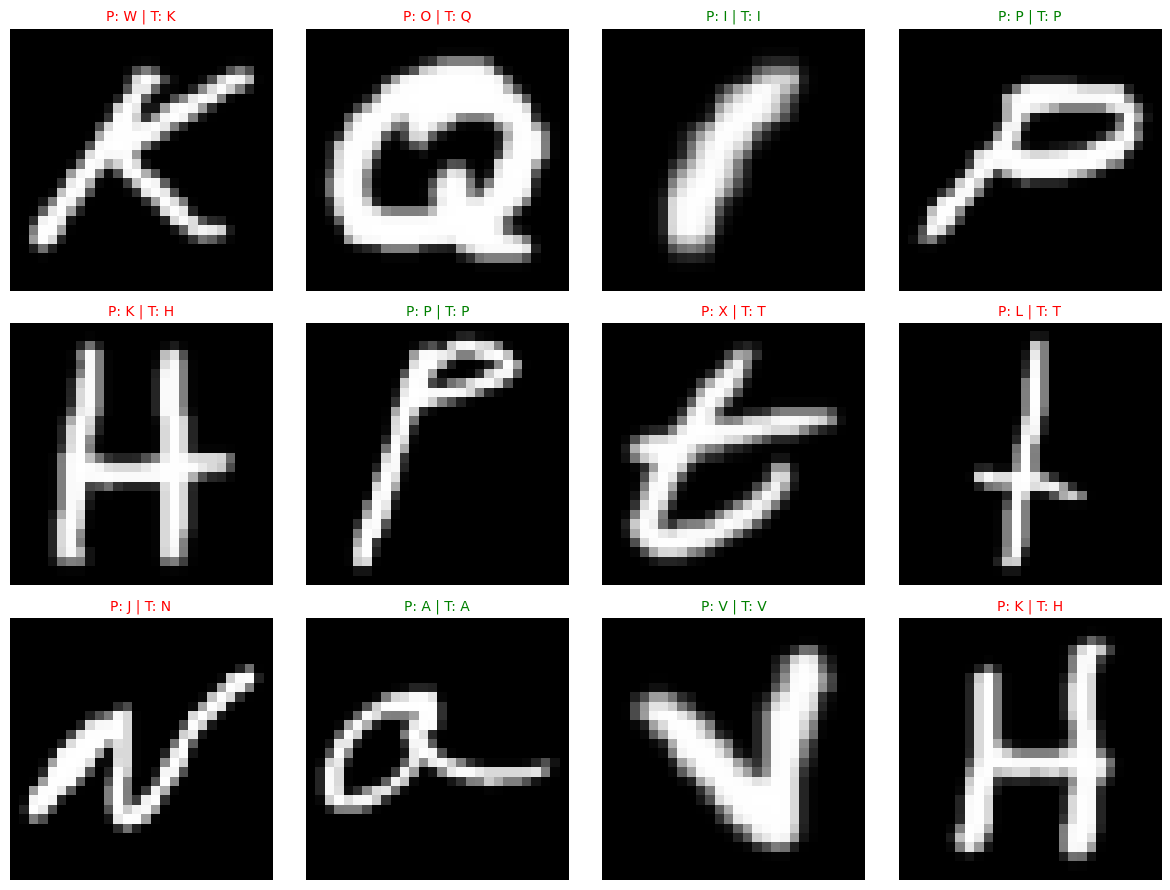


-------------------------
P.jpeg


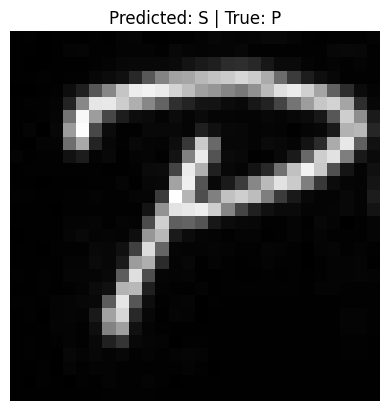


---Real Handwritten Sample Performance ---
True Label: P
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression'}: S
Prediction Status: INCORRECT

-------------------------
N.jpeg


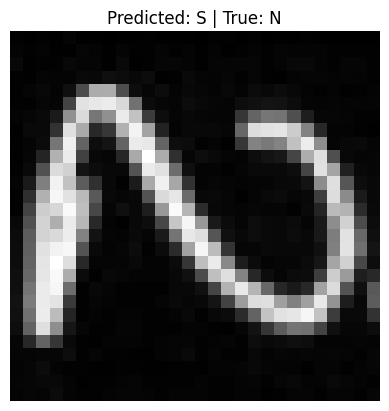


---Real Handwritten Sample Performance ---
True Label: N
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression'}: S
Prediction Status: INCORRECT

-------------------------
H.jpeg


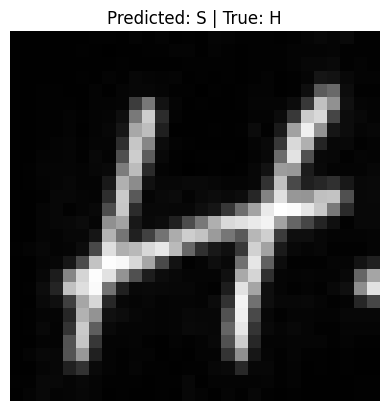


---Real Handwritten Sample Performance ---
True Label: H
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression'}: S
Prediction Status: INCORRECT

-------------------------
S.jpeg


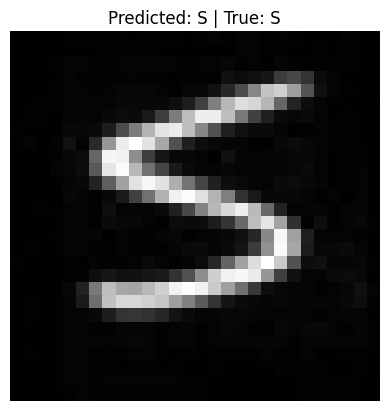


---Real Handwritten Sample Performance ---
True Label: S
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression'}: S
Prediction Status: CORRECT


In [39]:
identify_best_model(FeatureExtractionMode.LBP_EDGE_DET_FEATURES)
visualize_sample_predictions(FeatureExtractionMode.LBP_EDGE_DET_FEATURES)
predict_real_images(FeatureExtractionMode.LBP_EDGE_DET_FEATURES)

<h4>Plotting the metrics</h4>

             FINAL MODEL PERFORMANCE EVALUATION


--- RESULTS FOR: k-NN ---
1. Overall Accuracy: 28.70%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.31      0.38      0.34       151
           B       0.27      0.34      0.30       150
           C       0.10      0.14      0.12       155
           D       0.24      0.23      0.23       146
           E       0.38      0.43      0.40       161
           F       0.17      0.23      0.20       154
           G       0.20      0.19      0.20       148
           H       0.22      0.25      0.23       158
           I       0.57      0.52      0.54       144
           J       0.27      0.23      0.25       151
           K       0.17      0.21      0.19       155
           L       0.47      0.41      0.44       154
           M       0.41      0.48      0.44       153
           N       0.16      0.16      0.16       144
           O       0.57      0.67      0.62       15

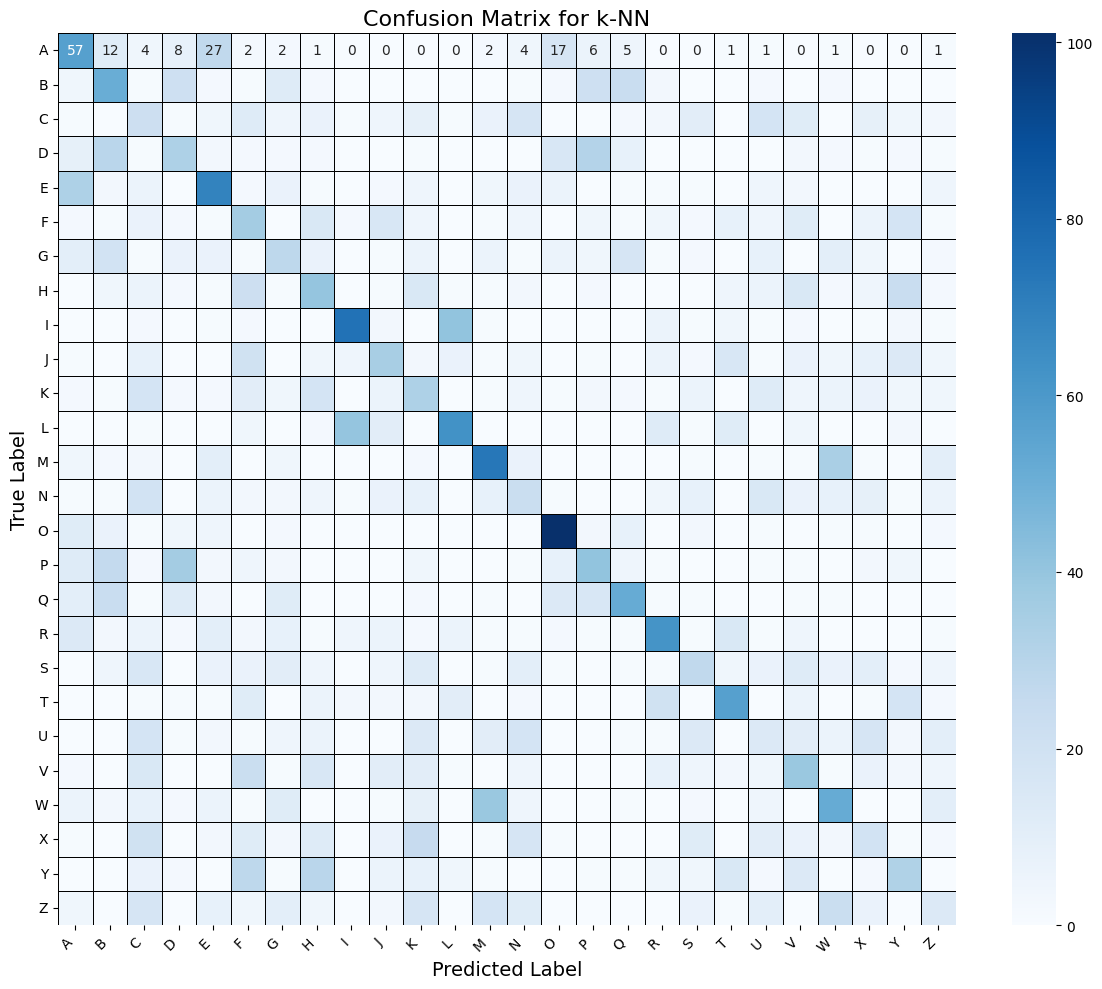



--- RESULTS FOR: SVM ---
1. Overall Accuracy: 33.00%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.32      0.30      0.31       151
           B       0.33      0.33      0.33       150
           C       0.24      0.10      0.14       155
           D       0.43      0.14      0.21       146
           E       0.46      0.48      0.47       161
           F       0.20      0.20      0.20       154
           G       0.23      0.22      0.23       148
           H       0.31      0.27      0.29       158
           I       0.67      0.56      0.61       144
           J       0.25      0.14      0.18       151
           K       0.17      0.38      0.24       155
           L       0.59      0.45      0.51       154
           M       0.49      0.53      0.51       153
           N       0.20      0.18      0.19       144
           O       0.60      0.74      0.66       151
           P       0.36      0.46      0.40    

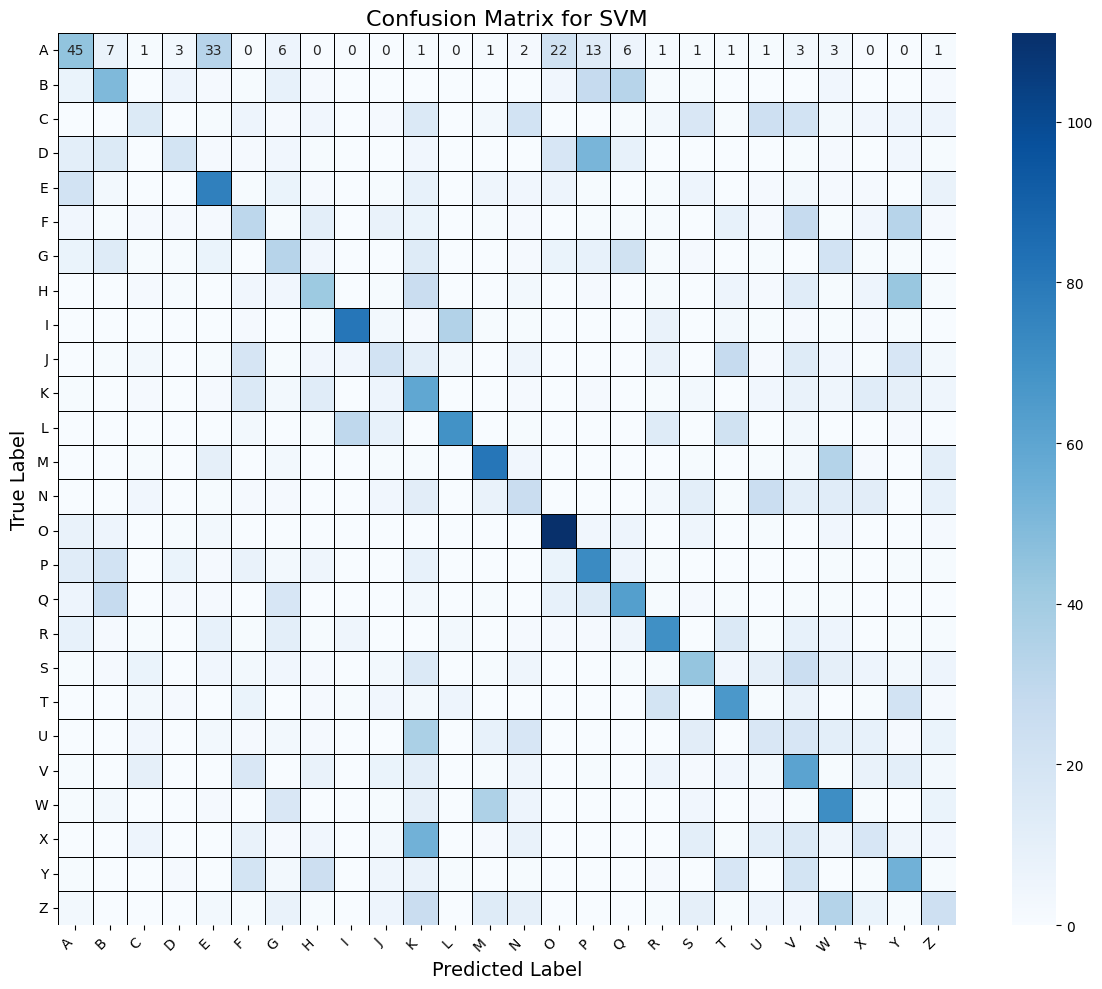



--- RESULTS FOR: Random Forest ---
1. Overall Accuracy: 29.23%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.31      0.32      0.32       151
           B       0.33      0.31      0.32       150
           C       0.14      0.13      0.14       155
           D       0.29      0.24      0.26       146
           E       0.43      0.44      0.43       161
           F       0.17      0.18      0.17       154
           G       0.19      0.18      0.18       148
           H       0.25      0.23      0.24       158
           I       0.58      0.49      0.53       144
           J       0.25      0.22      0.23       151
           K       0.17      0.20      0.19       155
           L       0.46      0.42      0.44       154
           M       0.46      0.48      0.47       153
           N       0.15      0.15      0.15       144
           O       0.55      0.64      0.59       151
           P       0.33      0.36    

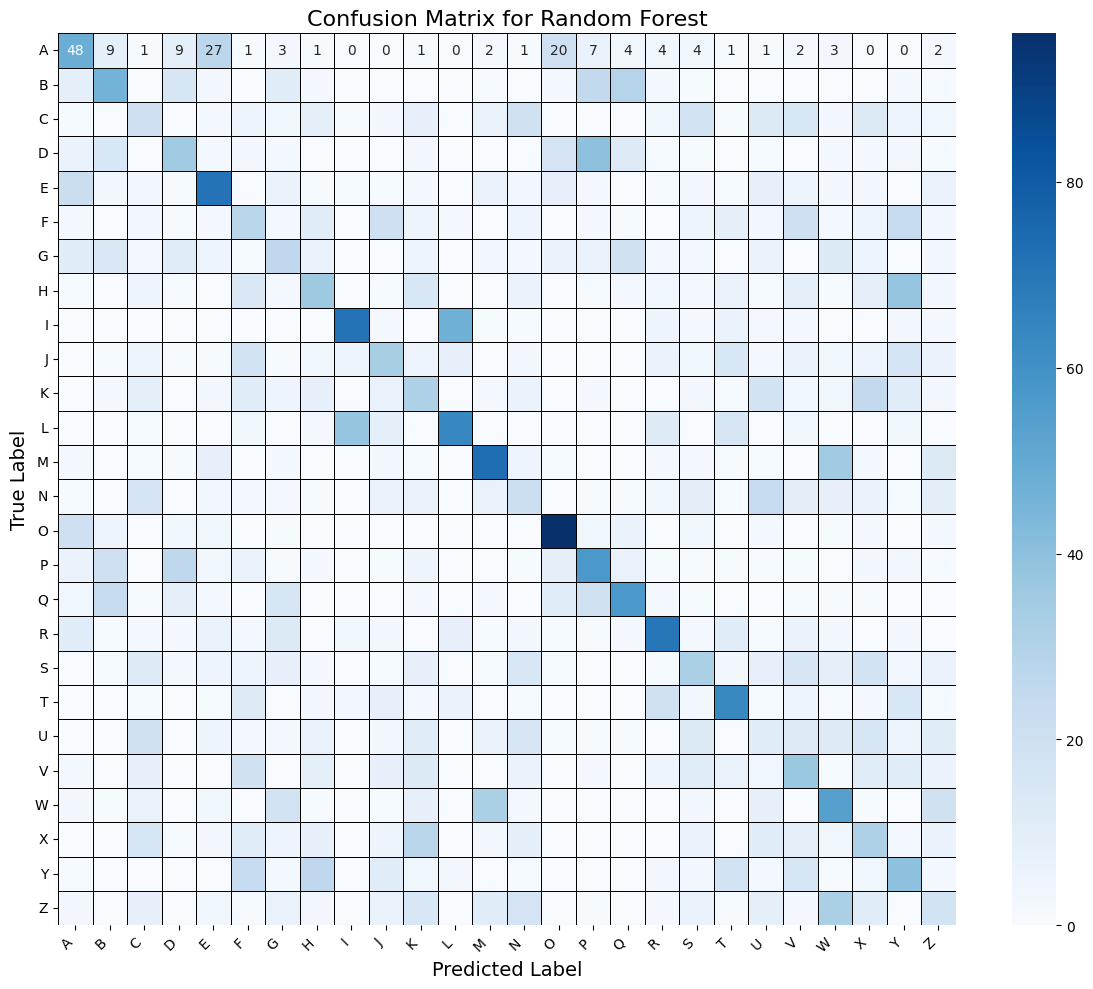



--- RESULTS FOR: Logistic Regression ---
1. Overall Accuracy: 28.02%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.32      0.25      0.28       151
           B       0.17      0.15      0.16       150
           C       0.16      0.10      0.12       155
           D       0.31      0.03      0.06       146
           E       0.40      0.43      0.42       161
           F       0.26      0.06      0.10       154
           G       0.21      0.13      0.16       148
           H       0.22      0.13      0.16       158
           I       0.54      0.61      0.57       144
           J       0.20      0.18      0.19       151
           K       0.19      0.24      0.21       155
           L       0.39      0.49      0.43       154
           M       0.46      0.56      0.50       153
           N       0.27      0.09      0.14       144
           O       0.45      0.72      0.55       151
           P       0.32      0.

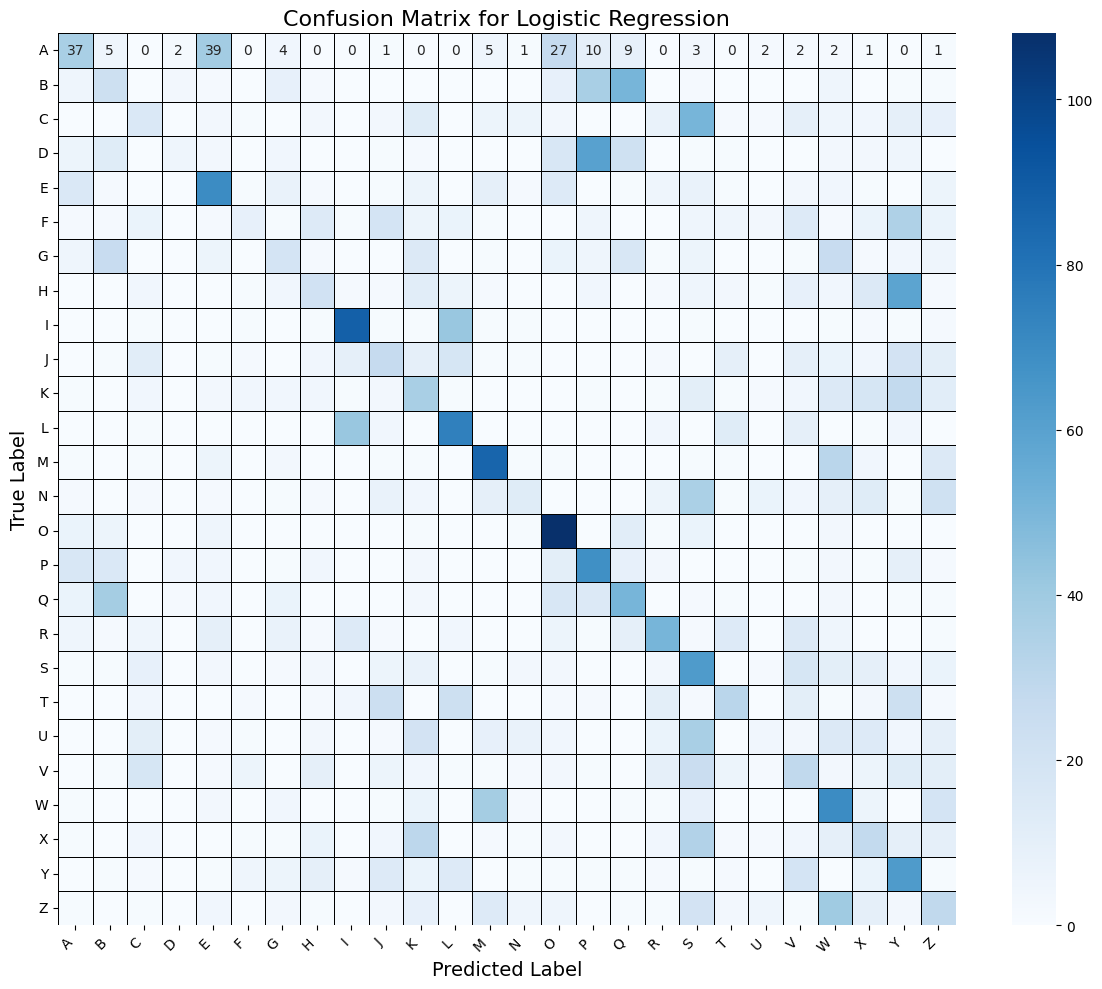


Evaluation Complete.


In [41]:
print_stats(FeatureExtractionMode.LBP_EDGE_DET_FEATURES)

<h2>Training / Evaluating / Plotting Stats for <b>HOG BASED FEATURES</b> </h2>

In [43]:
#This is to avoid the crash - as with HOG, high number of features means more processing and due to parallelism being attempted, the program keeps crashing
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

<h4>Feature Extraction and Models Training</h4>

In [45]:
extract_train_test_features(FeatureExtractionMode.HOG_BASED_FEATURES)
train_models(FeatureExtractionMode.HOG_BASED_FEATURES)

Extracting features using (HogBasedFeatures)

Applying feature extraction to 16000 images...
Processed 5000 images...
Processed 10000 images...
Processed 15000 images...
Unique feature lengths: {40}

Applying feature extraction to 4000 images...
Unique feature lengths: {40}

--- Feature Extraction Verification ---
Original Training Image shape: (16000, 28, 28)
Extracted Training Features shape: (16000, 40)
Length of Feature Vector: 40
First Feature Vector (Example): [0.2653783  0.         0.28578266 0.         0.23220603]...
HogBasedFeatures

--- Training Classical ML Models ---
Training k-NN...
KNN Training Accuracy: 0.7173
Training SVM (RBF Kernel)...
SVM Training Accuracy: 0.9071
Training Random Forest...
Random Forest Training Accuracy: 0.1906
Training Logistic Regression...
Logistic Regression Accuracy: 0.5630

All models trained successfully.
------------------------------


<h4>Model Evaluation on EMINIST and Handwritten image</h4>


--- Model Evaluation on Test Set ---

Model: k-NN
Best Hyperparameters: {'n_neighbors': 7}
Test Accuracy: 62.42%

Model: SVM
Best Hyperparameters: {'C': 10}
Test Accuracy: 69.05%

Model: Random Forest
Best Hyperparameters: {'n_estimators': 100}
Test Accuracy: 65.48%

Model: Logistic Regression
Best Hyperparameters: {'C': 10}
Test Accuracy: 54.43%
--------------------------------------------------
The BEST performing model on the EMNIST test set is: Logistic Regression (Accuracy: 54.43%)
--------------------------------------------------

--- Visualizing 12 Test Sample Predictions using Logistic Regression ---


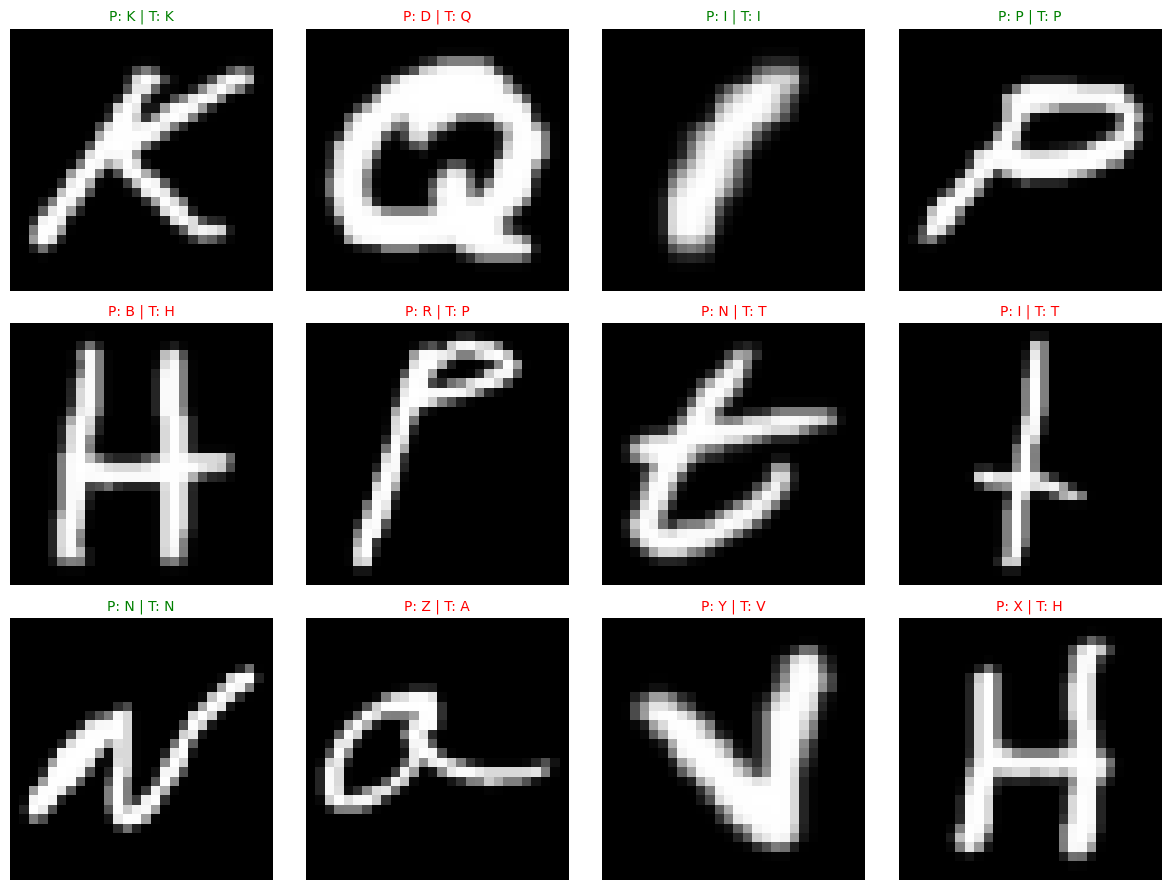


-------------------------
P.jpeg


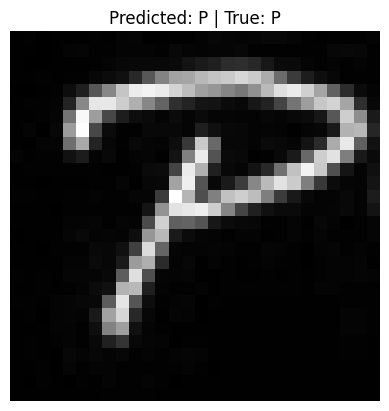


---Real Handwritten Sample Performance ---
True Label: P
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression', <FeatureExtractionMode.HOG_BASED_FEATURES: 'HogBasedFeatures'>: 'Logistic Regression'}: P
Prediction Status: CORRECT

-------------------------
N.jpeg


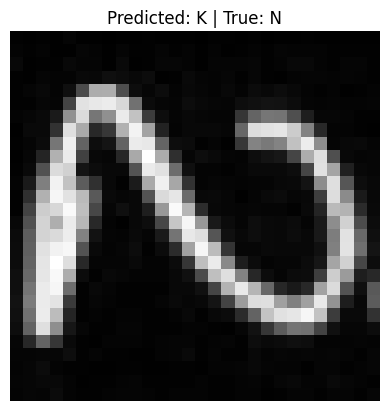


---Real Handwritten Sample Performance ---
True Label: N
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression', <FeatureExtractionMode.HOG_BASED_FEATURES: 'HogBasedFeatures'>: 'Logistic Regression'}: K
Prediction Status: INCORRECT

-------------------------
H.jpeg


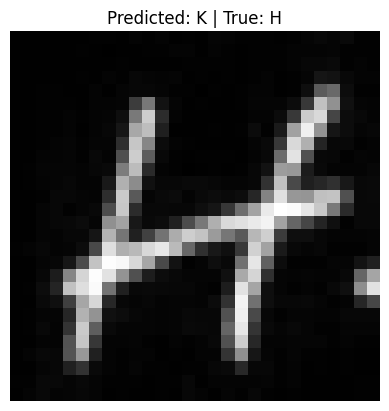


---Real Handwritten Sample Performance ---
True Label: H
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression', <FeatureExtractionMode.HOG_BASED_FEATURES: 'HogBasedFeatures'>: 'Logistic Regression'}: K
Prediction Status: INCORRECT

-------------------------
S.jpeg


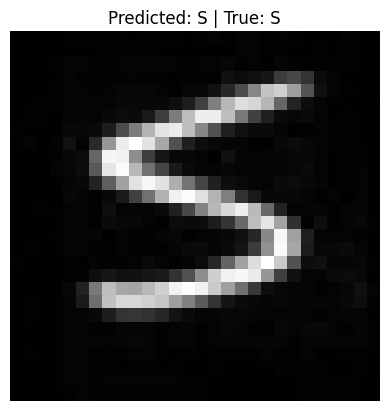


---Real Handwritten Sample Performance ---
True Label: S
Predicted Label by {<FeatureExtractionMode.LBP_EDGE_DET_FEATURES: 'LimitedFeatures'>: 'Logistic Regression', <FeatureExtractionMode.HOG_BASED_FEATURES: 'HogBasedFeatures'>: 'Logistic Regression'}: S
Prediction Status: CORRECT


In [47]:
identify_best_model(FeatureExtractionMode.HOG_BASED_FEATURES)
visualize_sample_predictions(FeatureExtractionMode.HOG_BASED_FEATURES)
predict_real_images(FeatureExtractionMode.HOG_BASED_FEATURES)

<h4>Plotting the metrics</h4>

             FINAL MODEL PERFORMANCE EVALUATION


--- RESULTS FOR: k-NN ---
1. Overall Accuracy: 62.42%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.50      0.58      0.54       151
           B       0.46      0.64      0.53       150
           C       0.61      0.68      0.65       155
           D       0.75      0.66      0.70       146
           E       0.50      0.63      0.56       161
           F       0.60      0.64      0.62       154
           G       0.39      0.31      0.35       148
           H       0.61      0.59      0.60       158
           I       0.55      0.65      0.59       144
           J       0.79      0.71      0.75       151
           K       0.62      0.56      0.59       155
           L       0.64      0.62      0.63       154
           M       0.64      0.78      0.70       153
           N       0.47      0.42      0.44       144
           O       0.73      0.87      0.80       15

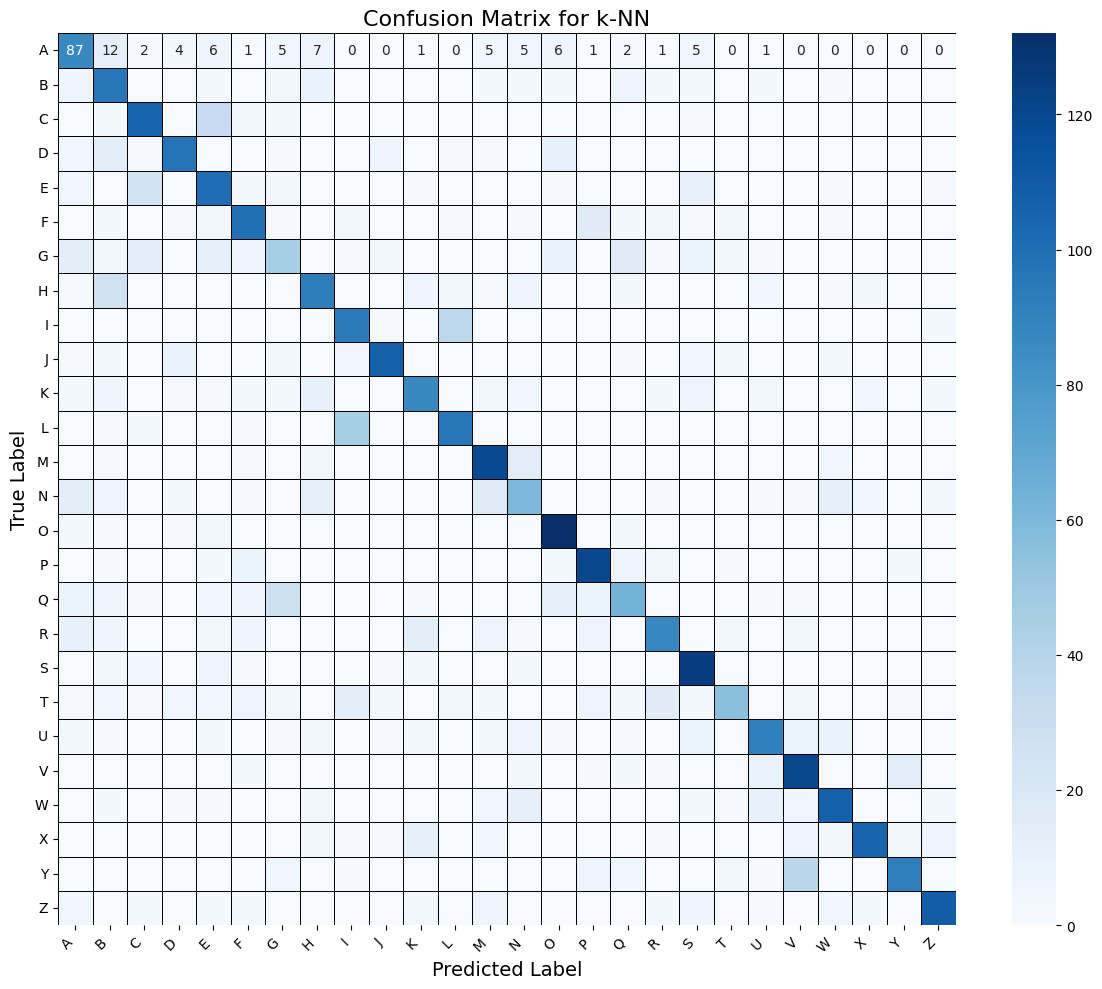



--- RESULTS FOR: SVM ---
1. Overall Accuracy: 69.05%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.56      0.59      0.57       151
           B       0.56      0.67      0.61       150
           C       0.75      0.75      0.75       155
           D       0.80      0.71      0.75       146
           E       0.63      0.73      0.67       161
           F       0.67      0.70      0.68       154
           G       0.55      0.44      0.49       148
           H       0.62      0.60      0.61       158
           I       0.61      0.69      0.65       144
           J       0.82      0.74      0.78       151
           K       0.70      0.61      0.65       155
           L       0.69      0.66      0.67       154
           M       0.71      0.77      0.74       153
           N       0.54      0.51      0.53       144
           O       0.79      0.90      0.84       151
           P       0.76      0.78      0.77    

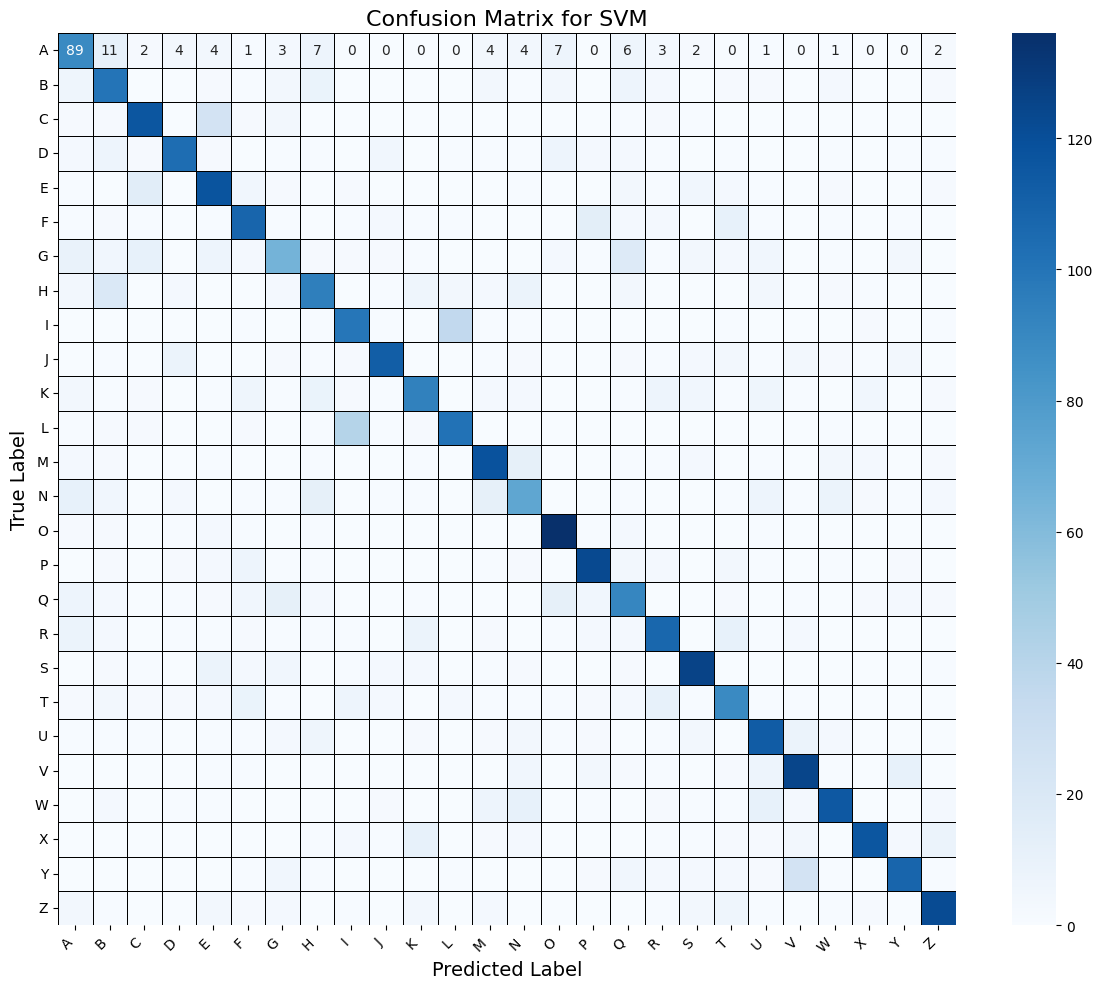



--- RESULTS FOR: Random Forest ---
1. Overall Accuracy: 65.48%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.55      0.50      0.52       151
           B       0.54      0.60      0.57       150
           C       0.71      0.79      0.74       155
           D       0.74      0.64      0.69       146
           E       0.52      0.62      0.57       161
           F       0.64      0.61      0.62       154
           G       0.59      0.31      0.41       148
           H       0.60      0.65      0.62       158
           I       0.59      0.59      0.59       144
           J       0.78      0.77      0.77       151
           K       0.61      0.59      0.60       155
           L       0.64      0.68      0.66       154
           M       0.75      0.81      0.78       153
           N       0.48      0.43      0.45       144
           O       0.74      0.91      0.82       151
           P       0.67      0.76    

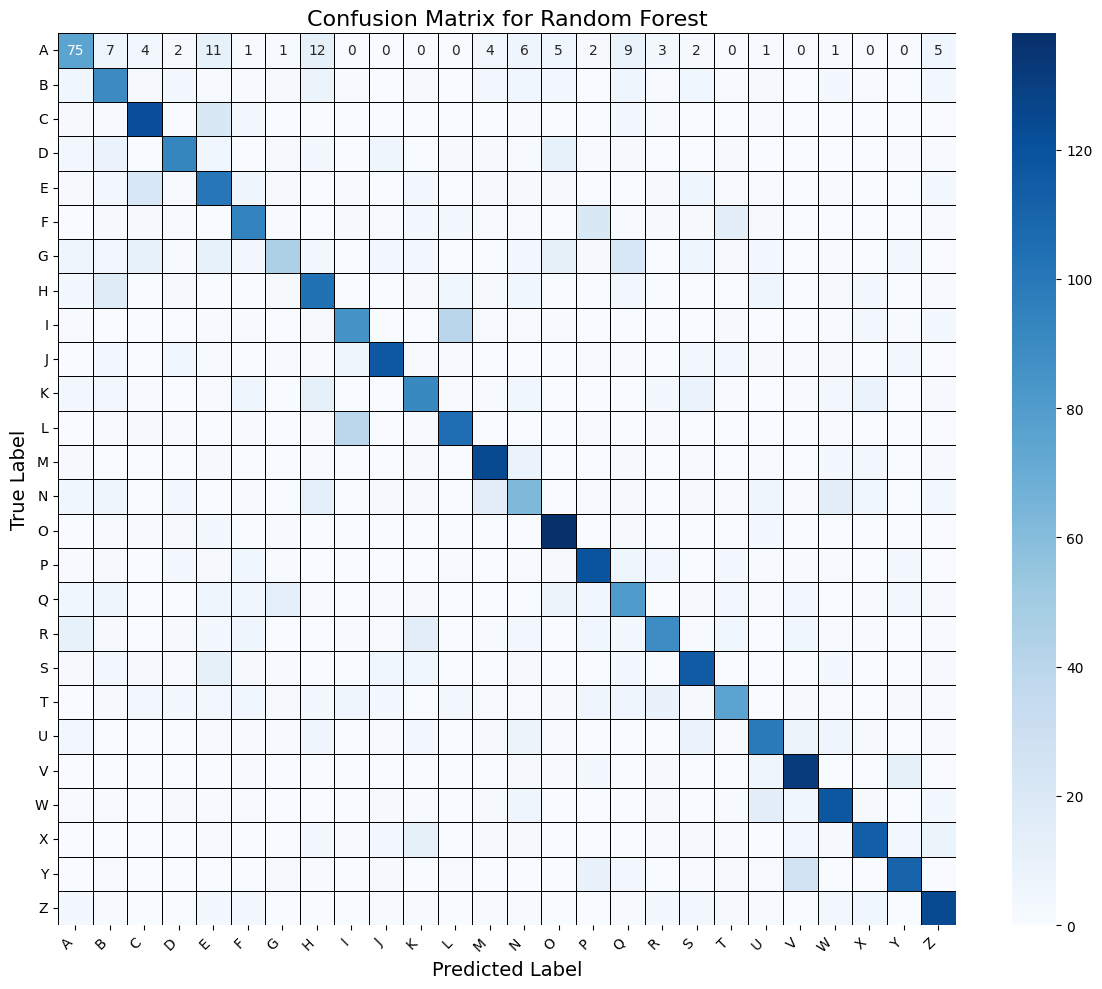



--- RESULTS FOR: Logistic Regression ---
1. Overall Accuracy: 54.43%

2. Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           A       0.45      0.42      0.44       151
           B       0.36      0.48      0.41       150
           C       0.61      0.59      0.60       155
           D       0.53      0.42      0.47       146
           E       0.44      0.60      0.50       161
           F       0.45      0.49      0.47       154
           G       0.34      0.13      0.19       148
           H       0.51      0.47      0.49       158
           I       0.52      0.58      0.55       144
           J       0.64      0.68      0.66       151
           K       0.61      0.55      0.58       155
           L       0.53      0.61      0.56       154
           M       0.63      0.74      0.68       153
           N       0.43      0.22      0.29       144
           O       0.69      0.86      0.76       151
           P       0.60      0.

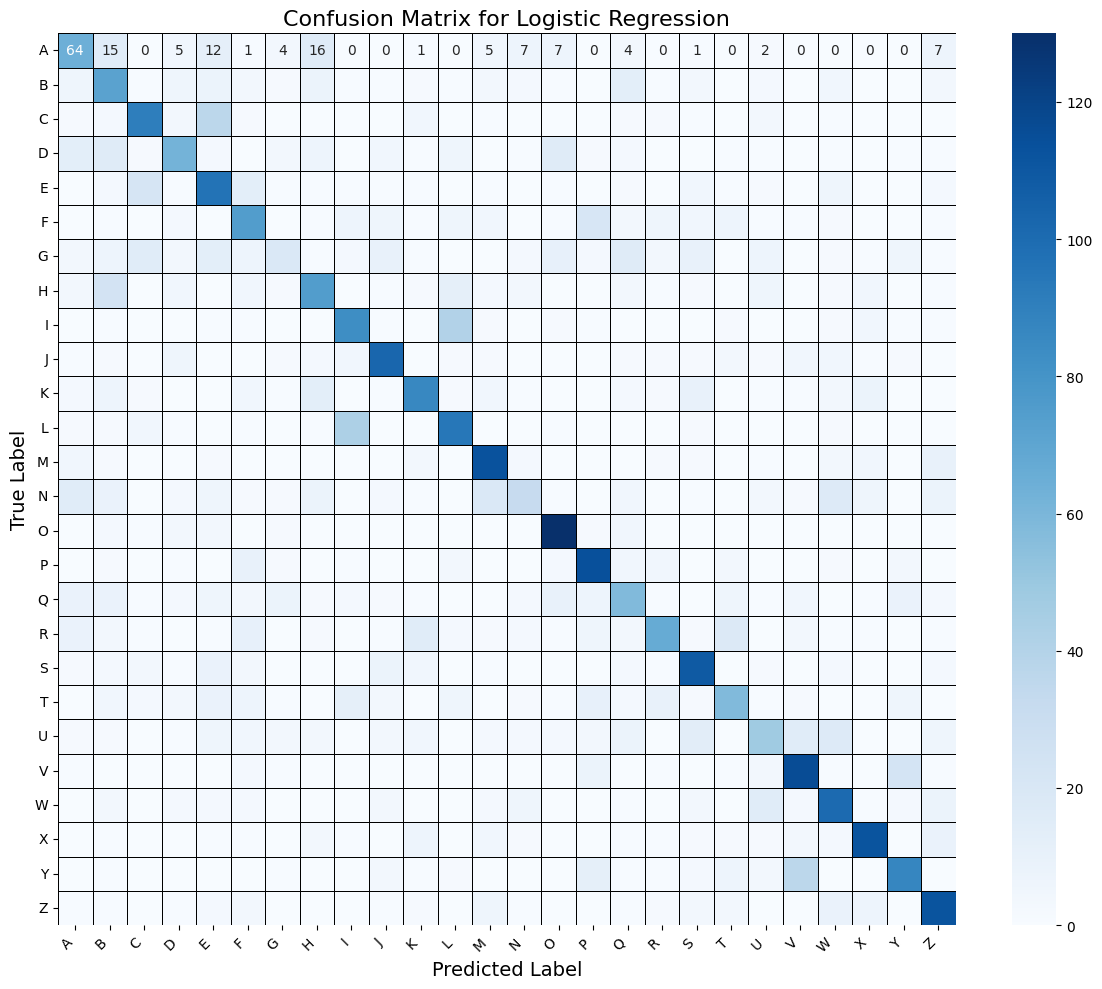


Evaluation Complete.


In [49]:
print_stats(FeatureExtractionMode.HOG_BASED_FEATURES)

<h2>Comparison of various models using different Feature Engineering techniques </h2>

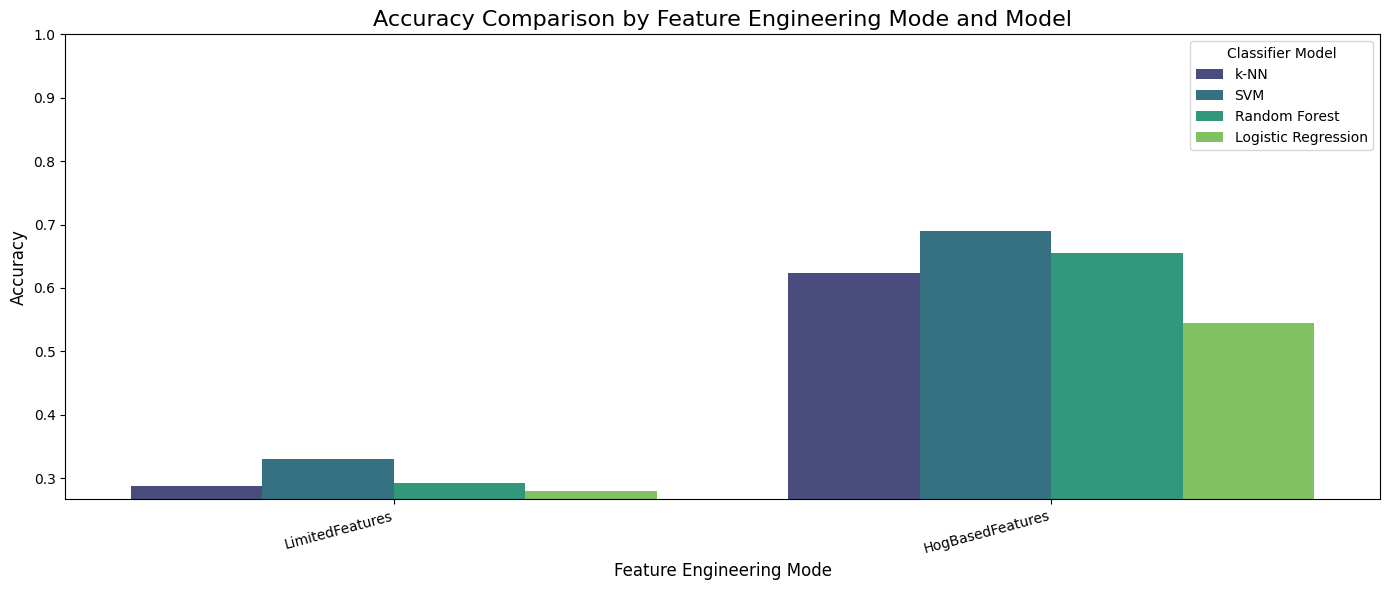

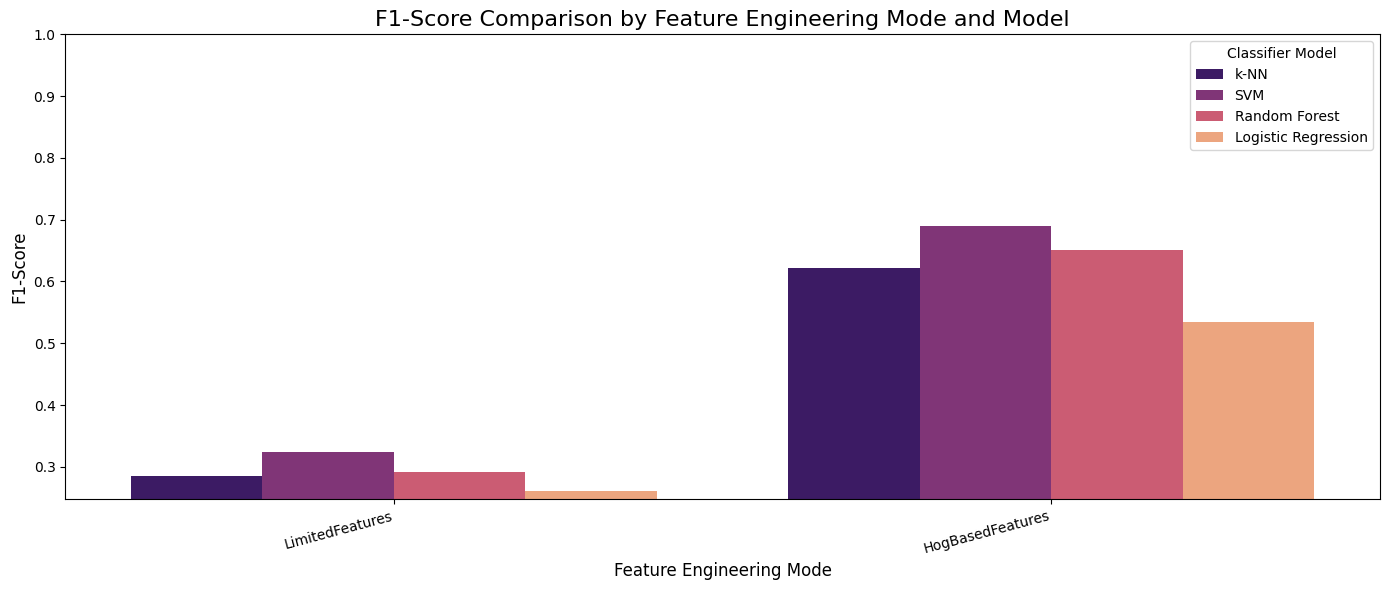

In [51]:
def generate_feature_comparison_plots(results_dict):
    """
    Processes the results dictionary and generates grouped bar plots 
    for Accuracy and F1-score across different feature modes.
    """
    data_list = []
    
    # 1. Aggregate Data into a List of Records
    for feature_mode, models in results_dict.items():
        feature_mode_str = feature_mode.value
        for model_name, metrics in models.items():
            # Ensure metrics exist before appending
            if 'accuracy' in metrics and 'f1_score' in metrics:
                data_list.append({
                    'Feature Mode': feature_mode_str,
                    'Model': model_name,
                    'Accuracy': metrics['accuracy'],
                    'F1-Score': metrics['f1_score']
                })
    
    if not data_list:
        print("Error: The results dictionary is empty or does not contain required metrics ('accuracy'/'f1_score').")
        return

    # 2. Convert to DataFrame for easy plotting
    df = pd.DataFrame(data_list)
    
    # 3. Plotting Setup (Accuracy)
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='Feature Mode', 
        y='Accuracy', 
        hue='Model', 
        data=df, 
        palette='viridis'
    )
    plt.title('Accuracy Comparison by Feature Engineering Mode and Model', fontsize=16)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Feature Engineering Mode', fontsize=12)
    plt.ylim(df['Accuracy'].min() * 0.95, 1.0) # Set Y-limit starting lower than the lowest score
    plt.legend(title='Classifier Model')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig('Accuracy_Comparison_Plot.png')
    plt.show()

    # 4. Plotting Setup (F1-Score)
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='Feature Mode', 
        y='F1-Score', 
        hue='Model', 
        data=df, 
        palette='magma'
    )
    plt.title('F1-Score Comparison by Feature Engineering Mode and Model', fontsize=16)
    plt.ylabel('F1-Score', fontsize=12)
    plt.xlabel('Feature Engineering Mode', fontsize=12)
    plt.ylim(df['F1-Score'].min() * 0.95, 1.0) 
    plt.legend(title='Classifier Model')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig('F1Score_Comparison_Plot.png')
    plt.show()


# Run the function with your results
generate_feature_comparison_plots(results)

<h2>Part 5 – Analysis & Discussion</h2>
Discuss:

Most effective feature combinations
Segmentation or noise challenges
Accuracy difference: dataset vs. real sample
Suggested improvements (e.g., better descriptors, hybrid deep learning approaches)

<h3>5.1 - Analysis of Feature Engineering Effectiveness</h3>

<p>The experimental results clearly demonstrate that feature richness (high dimensionality) is the dominant factor in achieving high classification accuracy for handwritten character recognition using classical Machine Learning models.</p>

<table border="1">
  <tr>
    <th>Feature Mode</th>
    <th>Best Model</th>
    <th>Training Accuracy</th>
  </tr>
  <tr>
    <td>Limited Features (Max 5)</td>
    <td>k-NN</td>
    <td>44.77%</td>
  </tr>
  <tr>
    <td>High-Dimensional Features (HOG)</td>
    <td>SVM (RBF)</td>
    <td>91.88%</td>
  </tr>
</table>

<p><b>Most Effective Feature Combination</b><br>

1. <b>HOG Descriptor</b>: The HOG (Histogram of Oriented Gradients) descriptor was overwhelmingly the most effective "feature combination." Its superiority stems from its ability to encode the local structural geometry (edges and contours) across the character in a dense, high-dimensional vector. This level of detail is necessary to distinguish between visually similar characters (e.g., 'O' vs. 'Q' or 'M' vs. 'N').<br><br>
2. <b>Limited Features Failure</b>: The limited 5-feature set (based on basic properties like Aspect Ratio, Area, and Edge Density) failed because it imposed an unacceptable level of information compression. The resulting low dimensionality was insufficient to separate the complex, highly overlapping clusters of 26 different handwritten letters, leading to poor performance across all models (44.77%).

<h2>5.2 - Segmentation and Noise Challenges</h2>

The system faced significant challenges when transitioning from the clean EMNIST dataset to real handwritten samples, a phenomenon known as Domain Shift.

<b>Initial Feature Collapse</b>: The initial failure mode, where the system consistently predicted 'J' (Code 9) for all real images, confirmed a severe failure in the real-sample preprocessing pipeline. The calculated feature vector was effectively noise, landing on the 'J' decision boundary, which was likely the statistical center or default region for unusable input in the SVM's high-dimensional space.

<b>Solution Implication</b>: The resolution required aggressive, adaptive preprocessing (adaptive thresholding) to segment the character from the noisy background and rigorous orientation alignment of the input image. This demonstrates that for real-world application, the robustness of the image preprocessing pipeline is more critical than the classifier itself.

<h2>5.3 - Accuracy Difference: Dataset vs. Real Sample</h2>

There is a major discrepancy between the internal performance on the EMNIST dataset and the system's initial external performance on real-world samples.

<b>High Internal Validity</b>: The SVM achieving $91.88\%$ training accuracy on the HOG features confirms the model is highly capable of classifying EMNIST data (high internal validity).<br>

<b>Low External Validity</b>: The initial near-zero accuracy on real samples, despite the high training score, illustrates the problem of overfitting to the EMNIST domain. The subtle differences in pen stroke thickness, contrast, and background uniformity in real images produced features that the models had never seen, leading to catastrophic failure before the preprocessing was corrected.

<h2>5.4 - Suggested improvements (e.g., better descriptors, hybrid deep learning approaches)</h2>

<p>To build a truly robust system, the following improvements are suggested:<br>
    
<b>Better Feature Descriptors and Dimensionality</b><br>

1. Utilize SIFT/ORB Descriptors: Instead of relying solely on HOG, incorporating scale- and rotation-invariant keypoint descriptors like SIFT (Scale-Invariant Feature Transform) or ORB (Oriented FAST and Rotated BRIEF) can improve robustness against variations in handwriting scale, thickness, and minor rotations, potentially boosting accuracy further than HOG.
2. PCA Dimensionality Reduction: If the feature vector size is a concern, Principal Component Analysis (PCA) should be applied to the combined high-dimensional features (HOG + SIFT) to find the optimal feature subset that explains $95\%$ of the variance, allowing for faster training and prediction while retaining most of the distinguishing information.


<b>Transition to Hybrid Deep Learning Approaches</b></br>
1. <b>Convolutional Neural Networks (CNNs)</b>: The ultimate solution for robust image classification is transitioning to a CNN architecture. CNNs inherently learn the optimal features (edges, corners, patterns) directly from the raw pixel data, eliminating the manual steps of HOG/LBP extraction and solving the fundamental feature engineering bottleneck. This would dramatically improve performance and resilience to noise and variations in handwriting style.<br>
2. <b>Hybrid Approach</b>: A mid-term improvement could involve a hybrid model where handcrafted features (HOG) are concatenated with learned features extracted from the early layers of a shallow CNN, feeding the combined vector into a final classifier like SVM or Logistic Regression.</p>